# 17. 확신하는 날은 고르게 오는가

## Overview

15번에서 모델이 확신하는 날만 골라 쓰면 적중률이 62.8% 에서 72.1% 로 오르고,
정직하게 재도 83.8% 가 유지되는 걸 봤습니다. 다만 그때 **행동하는 날이 전체의
12.7% 로 줄었습니다.**

그 12.7% 가 **어디에 있는지는 안 봤습니다.** 여기가 이 문서의 질문입니다.

## 왜 이게 15번 결론을 무너뜨릴 수 있나

연중 고르게 흩어져 있다면 "여덟 번에 한 번꼴로 확신이 오고 그때 창고에 넣는다"가
됩니다. **운영이 됩니다.**

특정 두어 달에 몰려 있다면 얘기가 다릅니다. 나머지 열 달은 모델이 아무 말도
안 하는 셈이라 **그 기간에는 도구가 없습니다.** 창고를 연중 빌려둘 수도 없습니다.

품목 쪽도 같습니다. 확신이 저장 못 하는 품목이나 정체 품목(피마늘·깐마늘)에
몰려 있으면 **쓸 수 있는 날은 12.7% 보다 훨씬 적습니다.**

## 판정 기준을 먼저 정합니다

결과를 보고 기준을 정하면 룩어헤드입니다(04·11번 교훈). 재기 전에 적습니다.

| 기준 | 합격선 | 왜 이 값인가 |
|---|---|---|
| **빈도** | 품목당 연 **20일 이상** | 월 1~2회는 나와야 출하 계획에 넣을 수 있습니다 |
| **분산** | 12개월 중 **8개월 이상** | 4개월까지는 비수기로 넘길 수 있습니다 |
| **집중도** | 상위 3품목이 전체의 **50% 미만** | 넘으면 사실상 3품목짜리 도구입니다 |
| **안정성** | 해마다 반복 | 특정 해에만 몰리면 미래에 못 씁니다 |

## 목차

1. 준비: 15번 재현
2. 가설
3. 얼마나 자주 오나 (빈도)
4. 언제 오나 (분산)
5. 해마다 같은가 (안정성)
6. 실행 가능 품목에 남는가
7. 결론

## 1. 준비: 15번 재현

15번과 똑같은 피처·폴드·하이퍼파라미터입니다. 확신도까지 그대로 만들고,
여기서는 **그 날들이 어디에 있는지**만 봅니다.

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import HistGradientBoostingClassifier

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())

STORAGE = {
    "시금치": 7, "상추": 10, "배추": 30, "양배추": 50, "무": 45, "감자": 45,
    "양파": 165, "얼갈이배추": 10, "알배기배추": 20, "깻잎": 7, "미나리": 7,
    "열무": 7, "파": 7, "풋고추": 14, "브로콜리": 14, "고구마": 60,
    "생강": 90, "깐마늘(국산)": 30, "피마늘": 180,
}
가능품목 = [k for k, v in STORAGE.items() if v >= 10]
중간지대 = ["상추", "얼갈이배추", "풋고추", "배추"]

# 판정 기준 (재기 전에 정한 값)
연간최소 = 20      # 품목당 연 20일
개월최소 = 8       # 12개월 중 8개월
집중상한 = 50      # 상위 3품목이 50% 미만
print(f"{len(df):,}행 | 품목 {len(items)}개")

24,078행 | 품목 19개


In [2]:
H = 7
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]

b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)


def g(c):
    return b.groupby("item")[c]


b["y"] = g("_logp").shift(-H) - b._logp
b["오름"] = b.y > 0
b["미래가격"] = g("price_kg_avg").shift(-H)
for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y", "미래가격"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)
    t = te[["item", "price_date", "month", "오름", "price_kg_avg", "미래가격"]].copy()
    t["오를확률"] = clf.predict_proba(te[FEATS])[:, 1]
    out.append(t)
r = pd.concat(out).reset_index(drop=True)
r["방향맞음"] = (r.오를확률 > 0.5) == r.오름
r["확신도"] = (r.오를확률 - 0.5).abs()
r["연"] = r.price_date.dt.year
r["넣는다"] = r.오를확률 > 0.5      # 오른다고 봤으면 창고행

# 관측 기간(연 단위). 2026 은 8월까지라 부분 연도다.
기간연수 = (r.price_date.max() - r.price_date.min()).days / 365.25
print(f"준비 완료 ({time.time()-t0:.0f}초, {len(r):,}일, {기간연수:.2f}년)")
print(f"15번 재현 확인: 적중률 {r.방향맞음.mean()*100:.1f}% (15번 62.8%)")
for t in (0.20, 0.30):
    s = r[r.확신도 >= t]
    print(f"  확신도 >={t:.2f}: {len(s):,}일 ({len(s)/len(r)*100:.1f}%), "
          f"적중률 {s.방향맞음.mean()*100:.1f}%")

준비 완료 (11초, 15,762일, 3.57년)
15번 재현 확인: 적중률 62.8% (15번 62.8%)
  확신도 >=0.20: 5,080일 (32.2%), 적중률 72.1%
  확신도 >=0.30: 1,716일 (10.9%), 적중률 76.5%


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 확신하는 날은 품목에 쏠린다 | 상위 3품목이 전체의 50% 이상 |
| **H2** | 확신하는 날은 시기에 쏠린다 | 확신이 나오는 달이 8개월 미만 |
| **H3** | 쏠려 있어도 실행 가능 품목에 충분히 남는다 | 저장 10일 이상 품목만으로 기준 통과 |

**H1·H2 가 확인되면 15번 결론이 흔들립니다.** 반대로 반증되면 15번을 그대로
가져가도 됩니다.

**어느 쪽이든 정보입니다.** 쏠려 있다면 "쏠린 그 구간에 집중하는 도구"로
용도를 다시 정의하면 되고, 고르다면 연중 운영을 설계하면 됩니다.

### 두 임계값으로 봅니다

- **0.20**: 커버리지 약 32%. 느슨하게 걸러낸 상태
- **0.30**: 커버리지 약 11%. 15번 정직한 평가가 고른 값(평균 0.31)에 가까움

## 3. 얼마나 자주 오나

품목마다 **1년에 며칠**이나 확신하는 날이 나오는지 셉니다. 합격선은 연 20일
입니다: 월 1~2회는 나와야 출하 계획에 넣을 수 있습니다.

**여기서 세는 건 "확신하는 날"입니다.** 그중 "창고에 넣는 날"(오른다고 확신한
날)은 절반 정도일 테니 같이 봅니다.

In [3]:
def 빈도표(thr):
    s = r[r.확신도 >= thr]
    tot = len(s)
    rows = []
    for it in items:
        si = s[s.item == it]
        넣음 = si[si.넣는다]
        rows.append({
            "item": it,
            "확신 일수": len(si),
            "연평균 확신일": len(si) / 기간연수,
            "연평균 창고행": len(넣음) / 기간연수,
            "적중률 %": si.방향맞음.mean() * 100 if len(si) else np.nan,
            "전체 대비 %": len(si) / tot * 100 if tot else 0,
            "나온 개월수": si.month.nunique(),
        })
    return pd.DataFrame(rows).set_index("item")


for thr in (0.20, 0.30):
    f = 빈도표(thr).sort_values("연평균 확신일", ascending=False)
    f["빈도 합격"] = f["연평균 확신일"] >= 연간최소
    f["분산 합격"] = f["나온 개월수"] >= 개월최소
    print(f"\n{'='*70}\n확신도 >= {thr:.2f}")
    display(f.round(1))
    상위3 = f["전체 대비 %"].nlargest(3)
    print(f"상위 3품목: {', '.join(상위3.index)} = {상위3.sum():.1f}% "
          f"(합격선 {집중상한}% 미만)")
    print(f"빈도 합격 {int(f['빈도 합격'].sum())}/{len(f)}품목 · "
          f"분산 합격 {int(f['분산 합격'].sum())}/{len(f)}품목")


확신도 >= 0.20


,확신 일수,연평균 확신일,연평균 창고행,적중률 %,전체 대비 %,나온 개월수,빈도 합격,분산 합격
item,,,,,,,,
시금치,413,115.7,70.0,77.2,8.1,12,True,True
상추,357,100.0,52.4,80.7,7.0,12,True,True
미나리,341,95.5,52.1,79.5,6.7,12,True,True
깐마늘(국산),336,94.1,3.1,63.4,6.6,12,True,True
깻잎,335,93.8,52.4,74.0,6.6,12,True,True
풋고추,335,93.8,56.3,76.1,6.6,12,True,True
얼갈이배추,311,87.1,45.7,81.4,6.1,12,True,True
양배추,284,79.5,40.3,68.7,5.6,12,True,True
배추,283,79.3,50.1,72.1,5.6,12,True,True


상위 3품목: 시금치, 상추, 미나리 = 21.9% (합격선 50% 미만)
빈도 합격 18/19품목 · 분산 합격 18/19품목

확신도 >= 0.30


,확신 일수,연평균 확신일,연평균 창고행,적중률 %,전체 대비 %,나온 개월수,빈도 합격,분산 합격
item,,,,,,,,
시금치,180,50.4,33.3,88.9,10.5,8,True,True
얼갈이배추,137,38.4,23.0,83.2,8.0,11,True,True
배추,129,36.1,24.6,76.7,7.5,7,True,False
상추,124,34.7,19.9,86.3,7.2,11,True,True
깐마늘(국산),123,34.5,2.0,64.2,7.2,7,True,False
풋고추,120,33.6,21.8,74.2,7.0,12,True,True
양배추,119,33.3,22.1,65.5,6.9,8,True,True
미나리,116,32.5,19.6,76.7,6.8,9,True,True
브로콜리,105,29.4,23.2,82.9,6.1,8,True,True


상위 3품목: 시금치, 얼갈이배추, 배추 = 26.0% (합격선 50% 미만)
빈도 합격 12/19품목 · 분산 합격 10/19품목


## 4. 언제 오나

품목 × 월로 쪼갭니다. 특정 달이 비어 있으면 그 기간에는 도구가 없다는 뜻입니다.

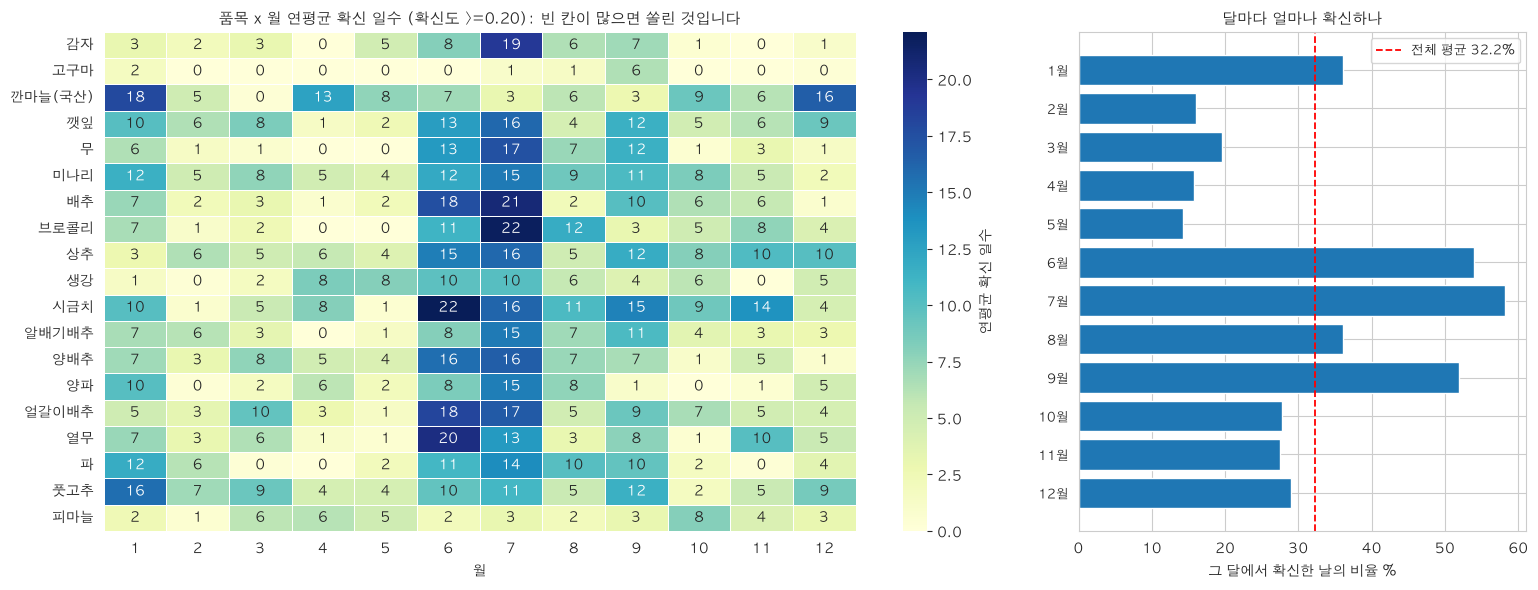

연평균 1일 미만인 달: 0개 / 12개월
확신이 나온 달: 12개 (합격선 8개 이상)

월별 연평균 확신 일수
month
1     145.1
2      60.5
3      81.8
4      66.9
5      54.6
6     221.8
7     261.1
8     116.8
9     152.9
10     81.5
11     91.0
12     88.8


In [4]:
thr = 0.20
s = r[r.확신도 >= thr]
piv = (s.groupby(["item", "month"]).size().unstack(fill_value=0)
        .reindex(index=items, columns=range(1, 13), fill_value=0))
piv_yr = (piv / 기간연수).round(1)

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6),
                         gridspec_kw={"width_ratios": [2.1, 1]})

ax = axes[0]
sns.heatmap(piv_yr, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "연평균 확신 일수"}, linewidths=0.4)
ax.set_title(f"품목 x 월 연평균 확신 일수 (확신도 >={thr:.2f}): "
             "빈 칸이 많으면 쏠린 것입니다", fontsize=11)
ax.set_xlabel("월")
ax.set_ylabel("")

ax = axes[1]
월합 = (s.groupby("month").size() / 기간연수).reindex(range(1, 13), fill_value=0)
전체월합 = (r.groupby("month").size() / 기간연수).reindex(range(1, 13), fill_value=0)
비율 = (월합 / 전체월합 * 100)
ax.barh(range(1, 13), 비율.values, color="tab:blue")
ax.axvline(len(s) / len(r) * 100, color="red", ls="--", lw=1.3,
           label=f"전체 평균 {len(s)/len(r)*100:.1f}%")
ax.set_yticks(range(1, 13))
ax.set_yticklabels([f"{m}월" for m in range(1, 13)], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("그 달에서 확신한 날의 비율 %")
ax.set_title("달마다 얼마나 확신하나", fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

빈달 = int((월합 < 1).sum())
print(f"연평균 1일 미만인 달: {빈달}개 / 12개월")
print(f"확신이 나온 달: {int((월합 > 0).sum())}개 (합격선 {개월최소}개 이상)")
print("\n월별 연평균 확신 일수")
print(월합.round(1).to_string())

## 5. 해마다 같은가

특정 해에만 몰려 있으면 미래에 못 씁니다. 연도별로 나눠 봅니다.
**2026년은 8월까지**라 부분 연도인 점을 감안해 읽습니다.

커버리지 %       적중률 %       나온 품목수      
임계값     0.2   0.3   0.2   0.3    0.2   0.3
연                                         
2023   32.0  11.9  61.9  67.2   19.0  18.0
2024   34.2  11.1  74.0  74.6   19.0  17.0
2025   31.4   9.4  78.3  85.4   19.0  18.0
2026   30.6  11.4  75.0  82.8   18.0  17.0

2026 은 8월까지라 관측일이 적습니다.


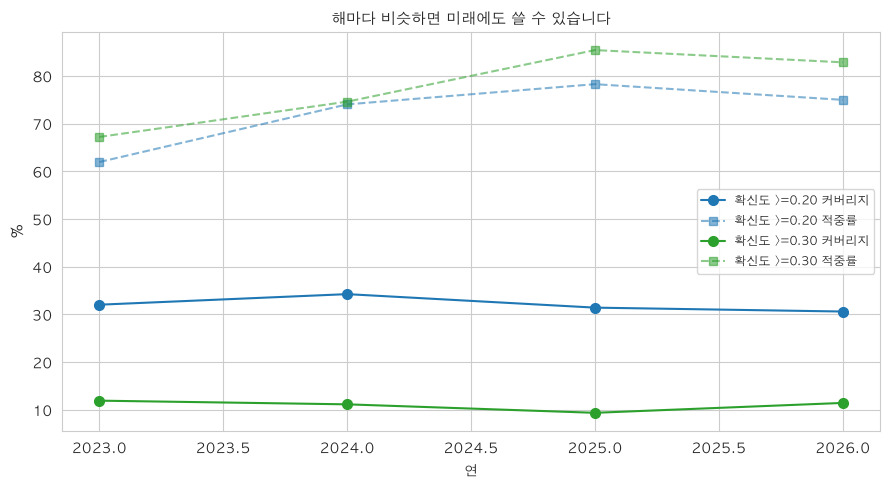

In [5]:
rows = []
for y, sy in r.groupby("연"):
    for t in (0.20, 0.30):
        c = sy[sy.확신도 >= t]
        rows.append({
            "연": y, "임계값": t,
            "관측일": sy.price_date.nunique(),
            "확신 일수": len(c),
            "커버리지 %": len(c) / len(sy) * 100,
            "적중률 %": c.방향맞음.mean() * 100 if len(c) else np.nan,
            "나온 품목수": c.item.nunique(),
        })
yr = pd.DataFrame(rows)
display(yr.pivot(index="연", columns="임계값",
                 values=["커버리지 %", "적중률 %", "나온 품목수"]).round(1))
print("2026 은 8월까지라 관측일이 적습니다.")

fig, ax = plt.subplots(figsize=(9, 5))
for t, c in ((0.20, "tab:blue"), (0.30, "tab:green")):
    sub = yr[yr.임계값 == t]
    ax.plot(sub.연, sub["커버리지 %"], "o-", ms=7, color=c,
            label=f"확신도 >={t:.2f} 커버리지")
    ax.plot(sub.연, sub["적중률 %"], "s--", ms=6, color=c, alpha=0.55,
            label=f"확신도 >={t:.2f} 적중률")
ax.set_xlabel("연")
ax.set_ylabel("%")
ax.set_title("해마다 비슷하면 미래에도 쓸 수 있습니다", fontsize=11)
ax.legend(fontsize=8.5)
plt.tight_layout()
plt.show()

## 6. 실행 가능 품목에 남는가

확신이 **저장 못 하는 품목**(시금치·미나리·깻잎·열무·파)이나 **정체 품목**
(피마늘·깐마늘)에 몰려 있으면, 12.7% 라는 숫자가 부풀려진 것입니다.
실제로 창고에 넣을 수 있는 날만 셉니다.

In [6]:
rows = []
for thr in (0.20, 0.30):
    s = r[r.확신도 >= thr]
    for label, sel in (("전체 19품목", items),
                       ("실행 가능 14품목", 가능품목),
                       ("중간지대 4품목", 중간지대)):
        sub = s[s.item.isin(sel)]
        넣음 = sub[sub.넣는다]
        base = r[r.item.isin(sel)]
        rows.append({
            "임계값": thr, "대상": label, "품목수": len(sel),
            "확신 일수": len(sub),
            "그 품목들 중 커버리지 %": len(sub) / len(base) * 100,
            "연평균 창고행 (품목당)": len(넣음) / 기간연수 / len(sel),
            "적중률 %": sub.방향맞음.mean() * 100 if len(sub) else np.nan,
        })
실행 = pd.DataFrame(rows)
display(실행.round(2))
print(f"'연평균 창고행 (품목당)' 이 {연간최소}일 이상이어야 운영에 넣을 수 있습니다.")
print("확신 일수의 절반쯤이 창고행입니다: 나머지는 '내린다'고 확신한 날입니다.")

,임계값,대상,품목수,확신 일수,그 품목들 중 커버리지 %,연평균 창고행 (품목당),적중률 %
0,0.2,전체 19품목,19,5080,32.23,39.11,72.13
1,0.2,실행 가능 14품목,14,3459,30.32,33.27,71.41
2,0.2,중간지대 4품목,4,1286,36.92,51.12,77.76
3,0.3,전체 19품목,19,1716,10.89,14.93,76.52
4,0.3,실행 가능 14품목,14,1180,10.34,13.14,73.73
5,0.3,중간지대 4품목,4,510,14.64,22.34,80.20


'연평균 창고행 (품목당)' 이 20일 이상이어야 운영에 넣을 수 있습니다.
확신 일수의 절반쯤이 창고행입니다: 나머지는 '내린다'고 확신한 날입니다.


## 7. 결론

### 한 줄 요약

**확신하는 날은 고르게 옵니다. 15번 결론은 무너지지 않습니다.**
다만 임계값 0.30 은 너무 높고, 정체 품목 셋은 창고에 넣을 날이 **아예 없습니다.**

### 가설 판정 (확신도 0.20 기준)

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 품목에 쏠린다 | 상위 3품목 **21.9%** (합격선 50% 미만) | **반증됨** |
| **H2** | 시기에 쏠린다 | **12개월 전부**에서 나옴, 빈 달 0개 | **반증됨** |
| **H3** | 실행 가능 품목에 충분히 남는다 | 품목당 연 **33.3일** 창고행 (합격선 20일) | **확인됨** |

미리 정한 네 기준을 모두 통과했습니다.

| 기준 | 합격선 | 결과 |
|---|---|---|
| 빈도 | 품목당 연 20일 | **18/19품목 통과** (고구마만 탈락) |
| 분산 | 12개월 중 8개월 | **18/19품목 통과** |
| 집중도 | 상위 3품목 50% 미만 | **21.9%** |
| 안정성 | 해마다 반복 | 커버리지 30.6~34.2% 로 4년 내내 안정 |

### 임계값 0.30 은 운영이 안 됩니다

15번의 정직한 평가가 고른 값(평균 0.31)이 실무에서는 너무 빡빡합니다.

| 임계값 | 빈도 합격 | 분산 합격 | 실행가능 품목당 연 창고행 |
|---|---|---|---|
| **0.20** | 18/19 | 18/19 | **33.3일** |
| 0.30 | 12/19 | 10/19 | 13.1일 (합격선 미달) |

0.30 에서는 절반 가까운 품목이 연 20일을 못 채웁니다. **적중률과 운영 가능성이
맞바꿈 관계**이고, 이 데이터에서는 **0.20 이 실용적인 지점**입니다.
중간지대 4품목만 보면 0.30 에서도 연 22.3일이라 겨우 통과합니다.

### 새로 드러난 것: 정체 품목은 창고행이 0 입니다

확신하는 날은 많은데 **전부 "내린다" 쪽**인 품목이 셋 있습니다.

| 품목 | 연평균 확신일 | 연평균 **창고행** | 뜻 |
|---|---|---|---|
| 피마늘 | 45.7일 | **0.0일** | 모델이 오른다고 확신한 적이 한 번도 없음 |
| 깐마늘(국산) | 94.1일 | 3.1일 | 사실상 없음 |
| 생강 | 59.9일 | 5.9일 | 사실상 없음 |

**출하 시점 결정에는 쓸 수 없는 품목입니다.** 14번에서 피마늘 창고비 한도가
-0.74% 로 나온 것과 같은 얘기를 다른 각도에서 보여줍니다. 10번에서 본 정체
(피마늘은 89.8% 의 날에 가격이 멈춤)가 원인으로 보이지만, 이건 관찰이지
증명이 아닙니다.

### 운영 지점

| 대상 | 품목당 연 창고행 | 적중률 |
|---|---|---|
| 실행 가능 14품목 | 33.3일 | 71.4% |
| **중간지대 4품목** | **51.1일** | **77.8%** |

중간지대 4품목은 **품목당 연 51일**, 대략 **주 1회꼴**로 창고에 넣습니다.
14·15번의 창고비 한도 16.2% 가 이 빈도 위에서 나온 숫자입니다.

### 계절 편중은 있습니다 (쏠림과는 다릅니다)

빈 달은 없지만 고르지도 않습니다.

| 달 | 연평균 확신 일수 |
|---|---|
| 7월 | 261 |
| 6월 | 222 |
| 9월 | 153 |
| 1월 | 145 |
| **5월** | **55** |

**7월이 5월의 4.8배**입니다. 여름에 확신이 몰리는데, 이건 "그 기간에 도구가
없다"가 아니라 "여름에 더 자주 쓴다"입니다. 판정 기준(8개월 이상)은 통과했으니
쏠림으로 보지 않되, **창고 용량 계획은 여름 기준으로 잡아야** 합니다.

### 한계

- **적중률이 해마다 오릅니다**: 2023년 61.9% → 2025년 78.3%. 폴드가 뒤로 갈수록
  학습 데이터가 쌓이니 자연스럽지만, **우연일 수도 있습니다.** 2026은 8월까지라
  부분 연도입니다.
- **고구마는 사실상 제외 대상**입니다: 연 10.9일뿐이고 5개월에서만 나옵니다.
- **합격선 네 개는 제가 정한 값**입니다. 연 20일·8개월이라는 기준 자체가
  현장에서 맞는지는 확인이 필요합니다.
- **창고 용량 제약을 안 넣었습니다.** 여름에 몰릴 때 그 물량을 다 넣을 창고가
  있는지는 별개 문제입니다.

### 다음

1. **중간지대 4품목 전용 모델** (다음 할 일 2번): 운영 지점이 확인됐으니
   이제 그 넷에 집중할 근거가 생겼습니다.
2. **정체 품목 셋을 대상에서 뺄지 결정**: 피마늘·깐마늘·생강은 출하 결정에
   쓸 수 없습니다. 다른 용도(구매 시점)로는 쓸 수 있는지 따로 봐야 합니다.
3. **창고비 실측치** (다음 할 일 4번): 이제 빈도까지 나왔으니
   "연 51회 × 7거래일" 기준으로 비용을 물을 수 있습니다.